<a href="https://colab.research.google.com/github/junggeyy/gis-notebooks/blob/main/site_suitability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Site Suitability Analysis

This notebook will contain a phase by phase breakdown and process of a site suitability analysis project, for a Fire Station, in Kathmandu Metropolitan City.

### Problem Definition and Criteria Selection


In [ ]:
%pip install rioxarray

In [2]:
import geopandas as gpd
import os
import rasterio
import rioxarray
import matplotlib.pyplot as plt

### Data Acqusition

In [3]:
data_path = '/content/drive/MyDrive/project_srcs/site-suitability-analysis/data'

boundary_file = 'nepal-municipalities.geojson'
roads_file = 'kmc-drivable-roads.geojson'
dem_file = 'ktm-dem.tif'

boundary_path = os.path.join(data_path, boundary_file)
roads_path = os.path.join(data_path, roads_file)
dem_path = os.path.join(data_path, dem_file)

In [4]:
nepal_boundary = gpd.read_file(boundary_path)
nepal_boundary.head()

,id,F_ID,N_ID,NAME,LEVEL,DISTRICT,geometry
0,None,104,bhaktapur-bhaktapur,Bhaktapur,Nagarpalika,Bhaktapur,"POLYGON ((85.44459 27.66441, 85.44378 27.66359..."
1,None,105,madhyapur -thimi-bhaktap,Madhyapur Thimi,Nagarpalika,Bhaktapur,"POLYGON ((85.36314 27.66892, 85.35419 27.66769..."
2,None,343,kathmandu-kathmandu,Kathmandu,Mahanagarpalika,Kathmandu,"POLYGON ((85.28577 27.68983, 85.28414 27.6927,..."
3,None,344,kirtipur-kathmandu,Kirtipur,Nagarpalika,Kathmandu,"POLYGON ((85.25319 27.64555, 85.25238 27.65416..."
4,None,396,chitwan -national -park-,Chitwan National Park,national-park,Makwanpur,"POLYGON ((84.71727 27.56355, 84.71727 27.55945..."


In [5]:
nepal_boundary = nepal_boundary.set_index('N_ID')
ktm_boundary = nepal_boundary.loc[['kathmandu-kathmandu']]
ktm_boundary

,id,F_ID,NAME,LEVEL,DISTRICT,geometry
N_ID,,,,,,
kathmandu-kathmandu,None,343,Kathmandu,Mahanagarpalika,Kathmandu,"POLYGON ((85.28577 27.68983, 85.28414 27.6927,..."


<Axes: >

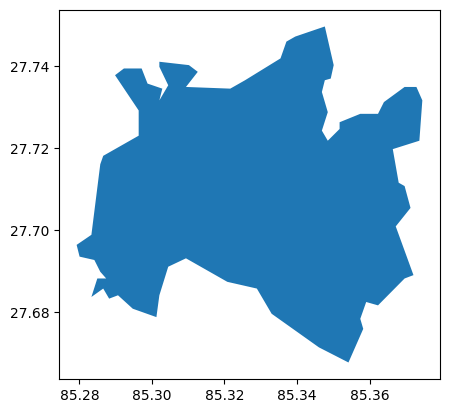

In [6]:
ktm_boundary.plot()

In [7]:
ktm_roads = gpd.read_file(roads_path)
ktm_roads.head()

,id,@id,FIXME,Household Code,Household Info By,access,addr:city,addr:place,addr:street,alt,...,trail_visibility,tunnel,type,vehicle,watch:80n,wheelchair,width,wikidata,wikipedia,geometry
0,way/220295107,way/220295107,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.31182 27.70238, 85.31181 27.70232..."
1,way/500866244,way/500866244,None,None,None,service,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.32289 27.69548, 85.32291 27.69555..."
2,way/1034447021,way/1034447021,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.35233 27.70185, 85.35233 27.70186..."
3,way/1174359027,way/1174359027,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.33708 27.68847, 85.33712 27.68847..."
4,way/1174944596,way/1174944596,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.33618 27.68923, 85.33628 27.68984..."


In [8]:
ktm_roads = ktm_roads[['@id', 'name', 'surface', 'smoothness', 'lanes', 'maxspeed', 'access', 'geometry']]
ktm_roads.head()

,@id,name,surface,smoothness,lanes,maxspeed,access,geometry
0,way/220295107,Te Bahal,asphalt,None,None,None,None,"POLYGON ((85.31182 27.70238, 85.31181 27.70232..."
1,way/500866244,None,None,None,None,None,service,"POLYGON ((85.32289 27.69548, 85.32291 27.69555..."
2,way/1034447021,None,None,None,None,None,None,"POLYGON ((85.35233 27.70185, 85.35233 27.70186..."
3,way/1174359027,None,None,None,None,None,None,"POLYGON ((85.33708 27.68847, 85.33712 27.68847..."
4,way/1174944596,None,None,None,None,None,None,"POLYGON ((85.33618 27.68923, 85.33628 27.68984..."


In [9]:
dem = rasterio.open(dem_path)

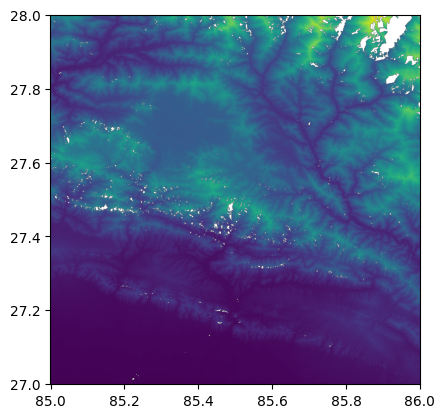

<Axes: >

In [10]:
from rasterio.plot import show

show(dem)

In [11]:
ktm_dem = rioxarray.open_rasterio(dem)

### Data Preprocessing

In [13]:
print("Current CRS:")
print(ktm_roads.crs)
print(ktm_boundary.crs)
print(ktm_dem.rio.crs)

ktm_roads = ktm_roads.to_crs('ESRI:102306')
ktm_boundary = ktm_boundary.to_crs('ESRI:102306')
ktm_dem = ktm_dem.rio.reproject("ESRI:102306")

print("\nAfter projection:")
print(ktm_roads.crs)
print(ktm_boundary.crs)
print(ktm_dem.rio.crs)

Current CRS:
ESRI:102306
ESRI:102306
ESRI:102306

After projection:
ESRI:102306
ESRI:102306
ESRI:102306


In [14]:
ktm_road_clipped = ktm_roads.clip(mask=ktm_boundary)
ktm_dem_clipped = ktm_dem.rio.clip(ktm_boundary.geometry)

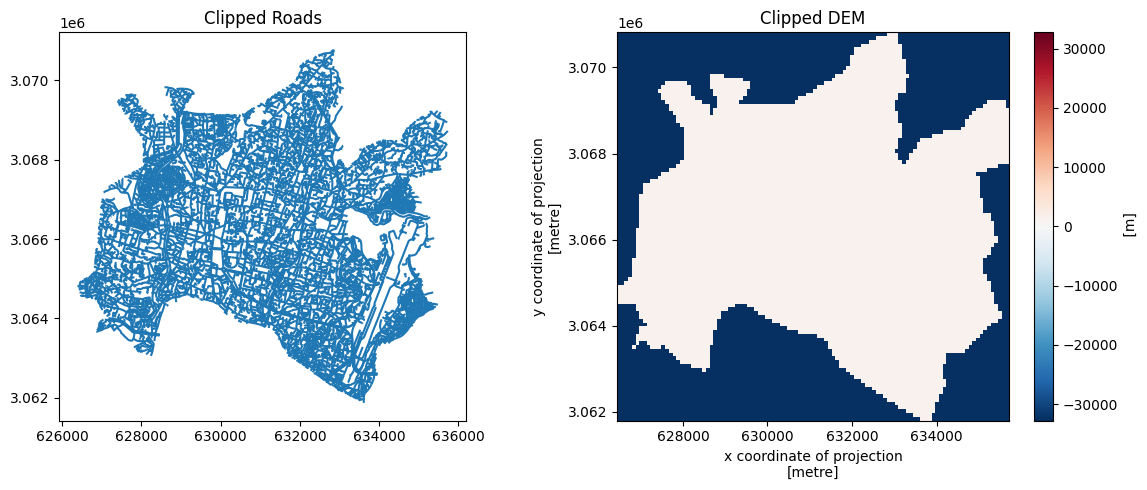

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ktm_road_clipped.plot(ax=ax[0])
ax[0].set_title("Clipped Roads")

ktm_dem_clipped.plot(ax=ax[1])
ax[1].set_title("Clipped DEM")

plt.tight_layout()
plt.show()

### Transformation and Standarization